## Demonstrate the segmentation by adaptive thresholding. 

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Basic Global Thresholding Function

In [1]:
def basic_global_thresholding(image, max_iterations=100, epsilon=0.5):
    T = np.mean(image)

    for _ in range(max_iterations):
        mask = image > T
        G1 = image[mask]
        G2 = image[~mask]

        if G1.size == 0 or G2.size == 0:
            break

        new_T = (np.mean(G1) + np.mean(G2)) / 2

        if abs(new_T - T) < epsilon:
            break

        T = new_T

    segmented = np.where(image > T, 255, 0).astype(np.uint8)
    return segmented, T

### Adaptive Thresholding function

In [3]:
def adaptive_thresholding(image, block_size=64):
    h, w = image.shape
    result = np.zeros_like(image, dtype=np.uint8)

    for r in range(0, h, block_size):
        for c in range(0, w, block_size):
            r_end = min(r + block_size, h)
            c_end = min(c + block_size, w)

            block = image[r:r_end, c:c_end]
            thresholded_block, _ = basic_global_thresholding(block)
            result[r:r_end, c:c_end] = thresholded_block

    return result


### Applying adaptive thresholding

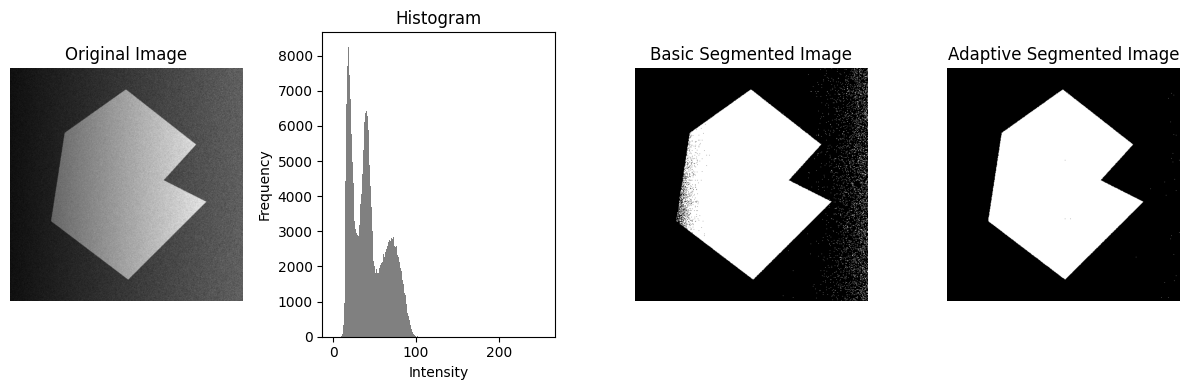

In [9]:
img = cv2.imread("./noisy_septagon.tif", 0)
img = cv2.resize(img, (512, 512))

hist = np.zeros(256)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        hist[img[i, j]] += 1

basic_segmented, _ = basic_global_thresholding(img)
adaptive_segmented = adaptive_thresholding(img, 256)

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.bar(range(256), hist, width=1.0, color = 'gray')
plt.title("Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 4, 3)
plt.imshow(basic_segmented, cmap='gray')
plt.title("Basic Segmented Image")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(adaptive_segmented, cmap='gray')
plt.title("Adaptive Segmented Image")
plt.axis('off')

plt.tight_layout()
plt.show()